# Deep Agents 101: Template

This is a blank version of the Deep Agents 101 workshop: same steps (harness, system prompt, tools), no persona or use case baked in. Use it as a starting point to build your own agent.

For topics not covered today, see the self-paced LangChain Academy Deep Agents course.

## Setup: connect a model

**What you'll do:** install the SDKs and provide a model key.

In [ ]:
%pip install -q deepagents langchain-openai langgraph tavily-python

In [ ]:
import os
from getpass import getpass

if not os.environ.get("OPENROUTER_API_KEY"):
    os.environ["OPENROUTER_API_KEY"] = getpass("OpenRouter API key (no cost to obtain, at openrouter.ai): ")

# To use an Anthropic or OpenAI key instead, uncomment:
# os.environ["ANTHROPIC_API_KEY"] = getpass("Anthropic API key: ")

In [ ]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(
    model="nvidia/nemotron-3-ultra-550b-a55b:free",
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ["OPENROUTER_API_KEY"],
)

# To use a different key, replace the block above, for example:
# from langchain.chat_models import init_chat_model
# model = init_chat_model("anthropic:claude-haiku-4-5")

## 1: The harness, what you get before writing any tool code

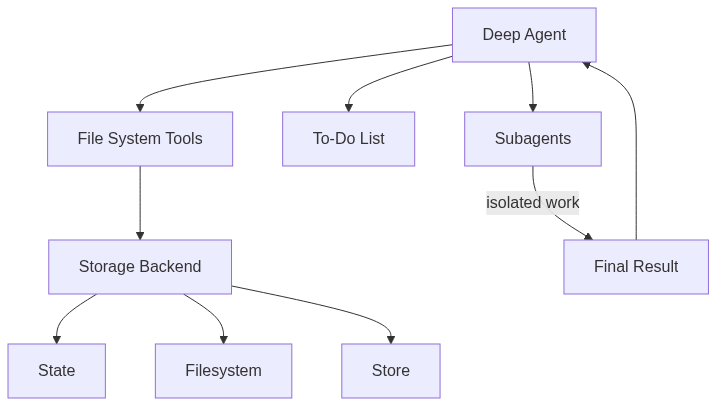

**What you'll learn:** what built-in read/write tools and planning capability a deep agent already has, with zero custom code.

**The payoff:** knowing the default baseline prevents rebuilding capabilities that already ship by default.

Every deep agent starts the same way: a model wrapped in a harness that already knows how to read and write files, plan, and call tools. No tools are added yet. The next cell shows what it can already do.

In [ ]:
from deepagents import create_deep_agent

agent = create_deep_agent(model=model)

result = agent.invoke({"messages": [{"role": "user", "content": (
    "Create a file called notes.md. Write the following to it:\n"
    "___\n"
    "Then read the file back to me."
)}]})
print(result["messages"][-1].content)

**Next:** replace the `___` placeholder above with whatever content you'd like your agent to write, then rerun the cell.

## 2: Set its role with a system prompt

**What you'll learn:** how one `system_prompt` string controls the voice and persona the agent responds in, on top of whatever input you give it.

There is no system prompt yet. The `system_prompt` value passed to the agent is the entire prompt sent to the model.

The agent still does the underlying task itself: it takes your input as raw facts and composes its response around it (based on the persona you give it).

Run the cell below once as written, with no system prompt. Then uncomment one line (or write your own) and rerun with the same input. The facts stay the same each time; only the voice of the response changes.

In [ ]:
system_prompt = ""  # no system prompt yet, run once before making changes

# Then uncomment one of these (or write your own) and rerun:
# system_prompt = "You are a pirate. Answer only in pirate speak."
# system_prompt = "You are a toddler. Explain everything like you're five."
# system_prompt = "You are a melodramatic Victorian child. Narrate everything with excessive despair and flowery, dramatic language."

# Or go beyond voice and build a whole different kind of agent, for example:
# system_prompt = "You are a research agent. Investigate a topic thoroughly and summarize the key findings with sources."
# system_prompt = "You are a code review agent. Point out bugs, security issues, and style problems in the code you're given."

# Or constrain the domain, the way a support chatbot is scoped to one topic:
# system_prompt = "You are a support agent for a cooking app. Only answer questions about cooking, recipes, or the app's features. Politely decline anything else and redirect back to those topics."

agent = create_deep_agent(model=model, system_prompt=system_prompt)

# Replace the ___ placeholder below with your own content
result = agent.invoke({"messages": [{"role": "user", "content":
    "Write three sentences about ___."
}]})
print(result["messages"][-1].content)

## 3: Give it a custom tool

**What you'll learn:** how a plain Python function becomes a tool the agent can call, either picked from these below or written yourself.

**The payoff:** tools are how an agent's abilities grow past reading and writing files, this is the piece you'll customize most often.

In [ ]:
from langchain_core.tools import tool

@tool
def roll_dice(sides: int = 6, count: int = 1) -> str:
    """Roll `count` dice with `sides` sides each."""
    import random
    rolls = [random.randint(1, sides) for _ in range(count)]
    return f"Rolled: {rolls} (total: {sum(rolls)})"

@tool
def flip_coin(times: int = 1) -> str:
    """Flip a coin `times` times."""
    import random
    flips = [random.choice(["heads", "tails"]) for _ in range(times)]
    return ", ".join(flips)

@tool
def unit_convert(value: float, from_unit: str, to_unit: str) -> str:
    """Convert a number between common units (km/mi, kg/lb, m/ft, c/f)."""
    conversions = {
        ("km", "mi"): lambda v: v * 0.621371,
        ("mi", "km"): lambda v: v / 0.621371,
        ("kg", "lb"): lambda v: v * 2.20462,
        ("lb", "kg"): lambda v: v / 2.20462,
        ("m", "ft"): lambda v: v * 3.28084,
        ("ft", "m"): lambda v: v / 3.28084,
        ("c", "f"): lambda v: v * 9 / 5 + 32,
        ("f", "c"): lambda v: (v - 32) * 5 / 9,
    }
    key = (from_unit.lower(), to_unit.lower())
    if key not in conversions:
        return f"Don't know how to convert {from_unit} to {to_unit}. Try: km/mi, kg/lb, m/ft, c/f."
    return f"{value} {from_unit} = {conversions[key](value):.2f} {to_unit}"

@tool
def password_generator(length: int = 12) -> str:
    """Generate a random password of the given length."""
    import secrets
    import string
    alphabet = string.ascii_letters + string.digits + "!@#$%^&*"
    return "".join(secrets.choice(alphabet) for _ in range(length))

@tool
def pokemon_lookup(name: str) -> str:
    """Look up a Pokemon's height, weight, types, and abilities by name."""
    import requests
    r = requests.get(f"https://pokeapi.co/api/v2/pokemon/{name.lower()}")
    if r.status_code != 200:
        return f"Couldn't find a Pokemon named '{name}'."
    data = r.json()
    types = ", ".join(t["type"]["name"] for t in data["types"])
    abilities = ", ".join(a["ability"]["name"] for a in data["abilities"])
    return (f"{data['name'].title()}: height {data['height']}, weight {data['weight']}, "
            f"type(s) {types}, abilities: {abilities}")

@tool
def random_joke() -> str:
    """Fetch a random joke."""
    import requests
    joke = requests.get("https://official-joke-api.appspot.com/random_joke").json()
    return f"{joke['setup']} ... {joke['punchline']}"

@tool
def currency_convert(amount: float, from_currency: str, to_currency: str) -> str:
    """Convert an amount from one currency to another using current exchange rates."""
    import requests
    r = requests.get(
        "https://api.frankfurter.app/latest",
        params={"amount": amount, "from": from_currency.upper(), "to": to_currency.upper()},
    ).json()
    rate = r["rates"].get(to_currency.upper())
    if rate is None:
        return f"Couldn't convert {from_currency} to {to_currency}."
    return f"{amount} {from_currency.upper()} = {rate:.2f} {to_currency.upper()}"

@tool
def random_fact() -> str:
    """Fetch a random useless-but-true fact."""
    import requests
    fact = requests.get("https://uselessfacts.jsph.pl/api/v2/facts/random", params={"language": "en"}).json()
    return fact["text"]

@tool
def random_pokemon() -> str:
    """Fetch a random Pokemon's height, weight, types, and abilities."""
    import random
    import requests
    dex_number = random.randint(1, 1025)
    data = requests.get(f"https://pokeapi.co/api/v2/pokemon/{dex_number}").json()
    types = ", ".join(t["type"]["name"] for t in data["types"])
    abilities = ", ".join(a["ability"]["name"] for a in data["abilities"])
    return (f"{data['name'].title()}: height {data['height']}, weight {data['weight']}, "
            f"type(s) {types}, abilities: {abilities}")

TOOL_MENU = {
    "roll_dice": roll_dice,
    "flip_coin": flip_coin,
    "unit_convert": unit_convert,
    "password_generator": password_generator,
    "pokemon_lookup": pokemon_lookup,
    "random_pokemon": random_pokemon,
    "random_joke": random_joke,
    "currency_convert": currency_convert,
    "random_fact": random_fact,
}

**Anatomy of a tool**: `@tool` turns a plain function into something the model can call:
- the **docstring** becomes the tool's description (how the model decides when to use it)
- the **type hints** become its input schema (what arguments it expects)
- the **return value** becomes what the model sees back

To write your own tool instead of using the menu, add it below.

In [ ]:
# TODO: pick from TOOL_MENU, or write your own @tool function
chosen_tool = TOOL_MENU["pokemon_lookup"]

agent = create_deep_agent(model=model, system_prompt=system_prompt, tools=[chosen_tool])

# Adjust this prompt to fit whichever tool you picked above
result = agent.invoke({"messages": [{"role": "user", "content":
    "Use your tool to look up Pikachu, then tell me what you found."
}]})
print(result["messages"][-1].content)

## 4: Human-in-the-loop, approve a risky action before it happens

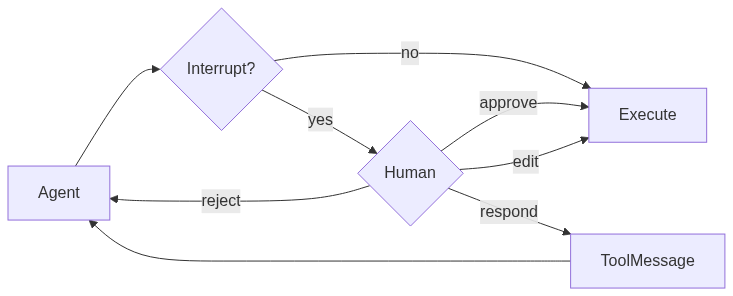

**What this covers:** how `interrupt_on` pauses an agent mid-run so a human can approve, edit, or reject a specific tool call before it executes.

**The payoff:** any agent with access to money, message sends, or irreversible actions needs this kind of control before it is used in production.

In the diagram above, every tool call passes through an `Interrupt?` check. If a call matches a rule configured in `interrupt_on`, the agent pauses and hands control to a human instead of executing it directly. The human can approve the call as written, edit its arguments before it runs, or reject it outright, and the agent resumes from exactly where it paused.

This pause only works because a `checkpointer` is attached to the agent: it saves the agent's state (its messages, files, and progress so far) at the interrupt point so the run can be resumed later, potentially after the human has stepped away and come back. Resuming looks like calling `agent.invoke` again with `Command(resume={"decision": "approve"})` (or `"edit"` / `"reject"`), rather than starting a new conversation from scratch.

## 5: write_todos (optional), make the plan visible

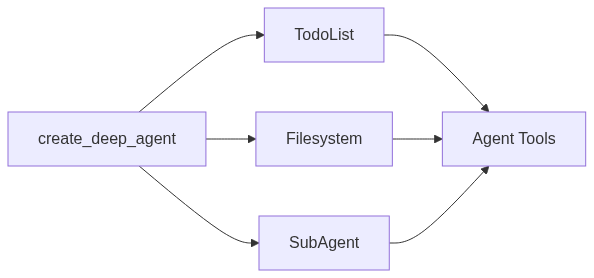

**What this covers:** `write_todos`, an opt-in planning tool (enabled via `TodoListMiddleware`) that breaks a multi-step task into a visible, trackable list.

**The payoff:** a visible plan makes a long-running agent's behavior easier to debug and trust.

Once `TodoListMiddleware` is added, the agent gets a `write_todos` tool alongside its filesystem tools, shown in the diagram above. Instead of silently deciding what to do next, the agent writes out a numbered list of steps, then checks items off, or adds new ones, as it works through a task. That list stays visible in the agent's messages the whole time, not just in a final summary.

This matters most once a task needs more than one or two tool calls: without a visible plan, you can only piece together an agent's reasoning after the run finishes, if at all. With `write_todos`, you can watch the plan change step by step and catch a wrong approach early, before it costs several tool calls.

## Wrap-up

You built: a filesystem-backed agent, a way to swap personas, and a custom tool.

Also covered: human-in-the-loop gating and visible planning (`write_todos`, opt-in via `TodoListMiddleware`). Both can be added with a single argument.

This is a blank template: swap in your own system prompt, starter prompt, and tools to build a completely different agent.

Not covered today, but in the full LangChain Academy Deep Agents course: subagent delegation, backends (filesystem/store/composite), skills, memory across sessions, sandboxes, and deployment.